In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
options(repr.plot.width = 15, repr.plot.height = 12)

In [5]:
names(Wage)

[1] "year"       "age"        "maritl"     "race"       "education" 
 [6] "region"     "jobclass"   "health"     "health_ins" "logwage"   
[11] "wage"

In [6]:
g1 = ggplot(Wage, aes(x=age, y=wage)) +
    geom_point() +
    geom_smooth()

In [7]:
g2 = ggplot(Wage, aes(x=year, y=wage)) + 
    geom_point() + 
    geom_smooth(method="lm")

In [8]:
g3 = ggplot(Wage, aes(x = education, y = wage, fill=education)) + 
  geom_boxplot() +
  stat_summary(fun = "mean", geom = "point", shape = 8,
    size = 2, color = "white")

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using formula = 'y ~ x'


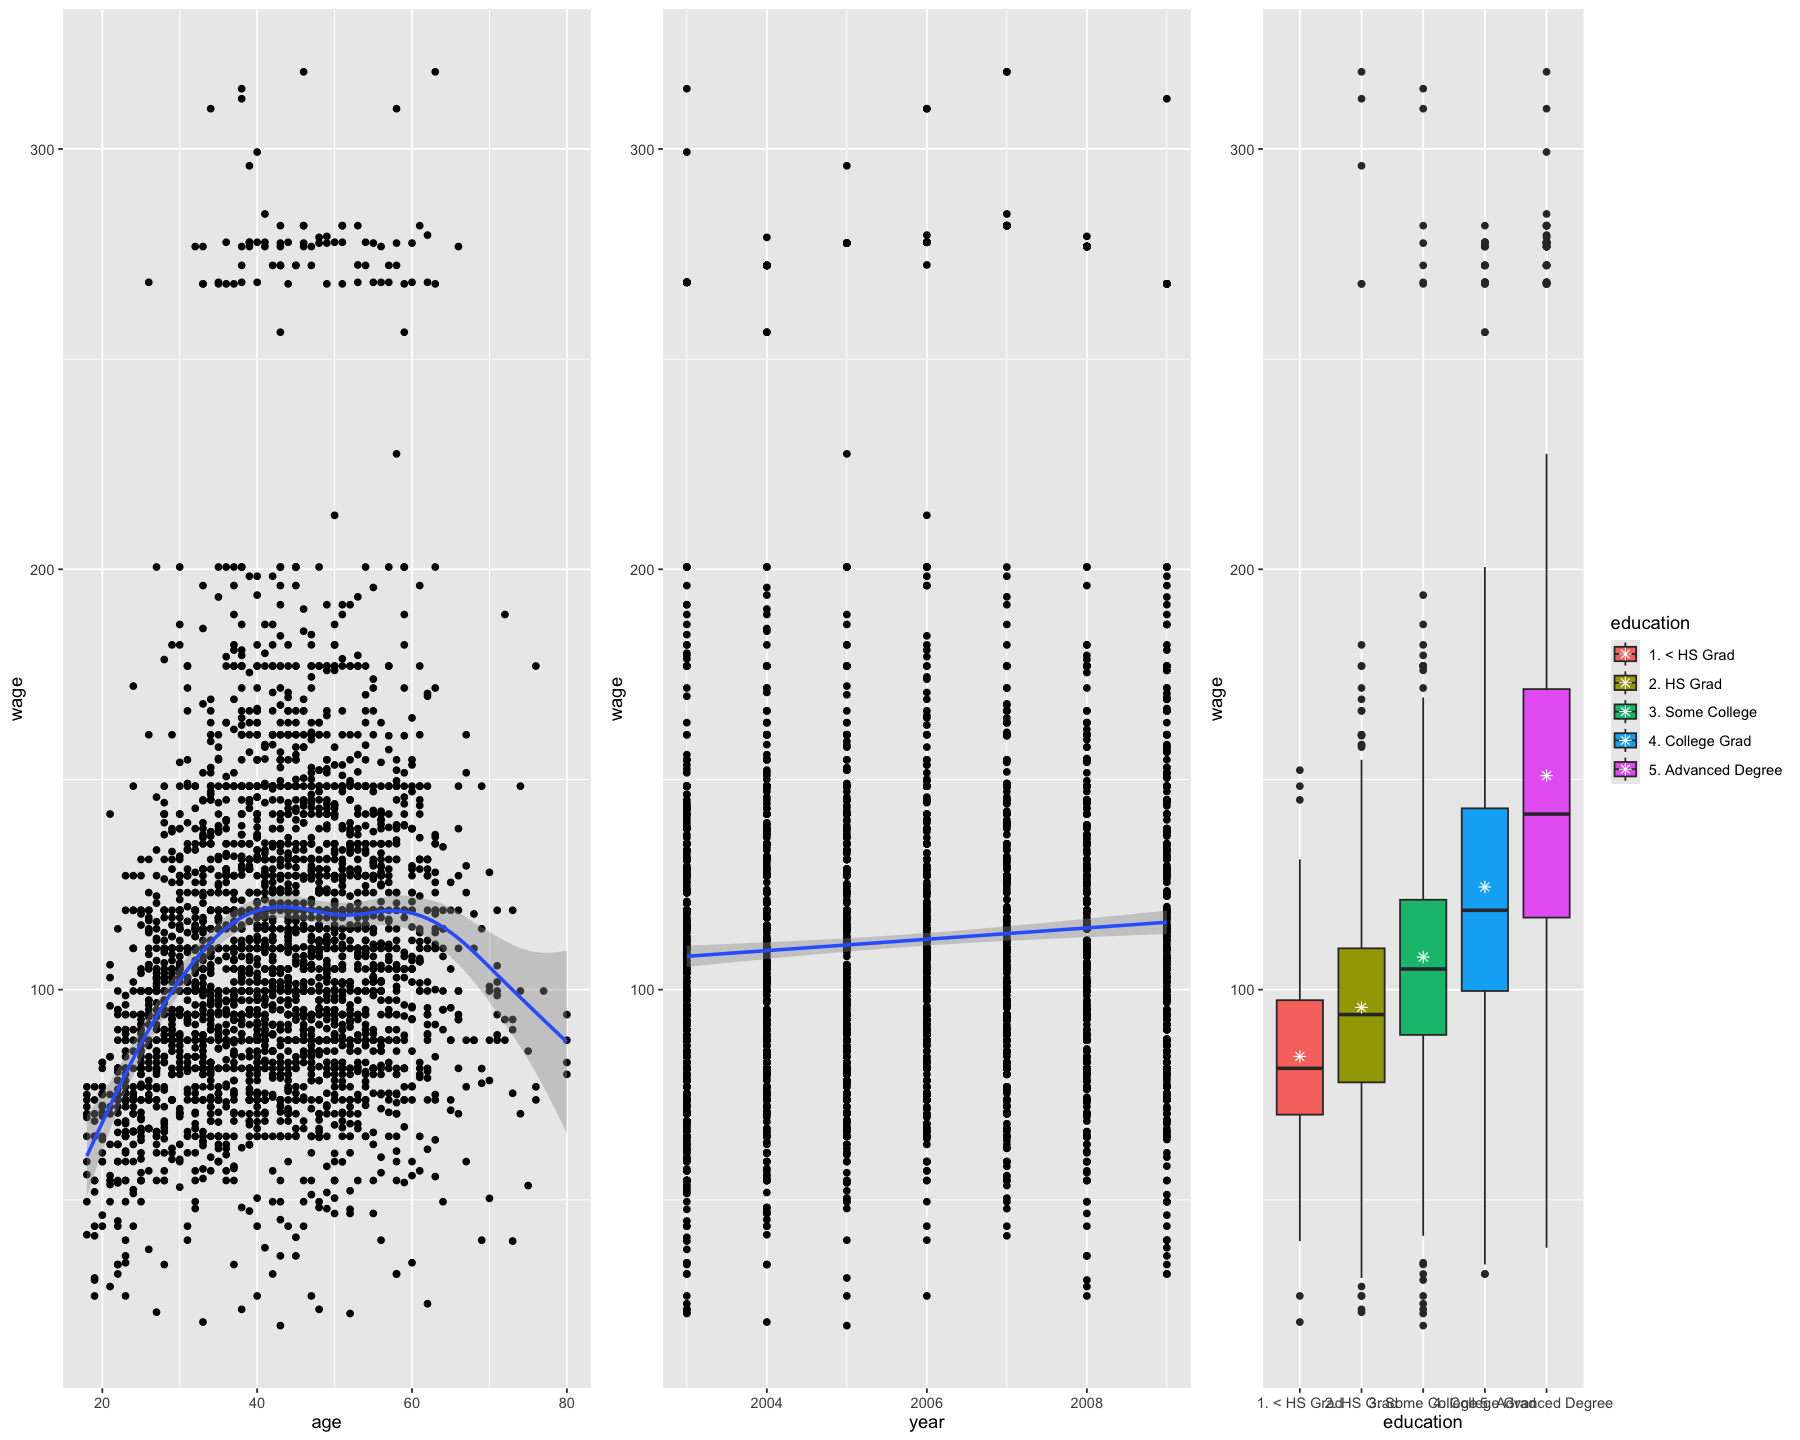

In [9]:
grid.arrange(g1, g2, g3, ncol = 3)

In [10]:
# artificial data
df <- data.frame(x = c(1:100))
df$y <- 2 + 3 * df$x + rnorm(100, sd = 40)
df$yy <- 2 + 3 * df$x + 0.1 * df$x^2 + rnorm(100, sd = 40)

In [11]:
# fitting a polynomial
f1 = ggplot(data = df, aes(x = x, y = yy)) +
  stat_poly_line(formula = x ~ poly(y, 2, raw = TRUE)) +
  stat_poly_eq(formula = x ~ poly(y, 2, raw = TRUE), use_label("eq")) +
  geom_point()

In [12]:
#Boston
df2 <- Boston
df2$x <- df2$lstat
df2$y <- 34.55384 - 0.95 * df2$lstat
df2$yy <- 42.862 - 2.333 * df2$lstat + 0.0435 * df2$lstat^2
 

In [13]:
f2 = ggplot(data = df2, aes(x = x, y = yy)) +
  stat_poly_line(formula = x ~ poly(y, 2, raw = TRUE)) +
  stat_poly_eq(formula = x ~ poly(y, 2, raw = TRUE), use_label("eq")) +
  geom_point()

In [14]:
devnum = c()
for (def in Default$default) {
  devnum = append(devnum, if (def == "No") 0 else 1)
}

Default$ndefault = devnum

In [15]:
f3 = ggplot(Default, aes(x=balance, y=ndefault)) +
  geom_point() +
  geom_smooth(method = "glm", 
      method.args = list(family = "binomial"), 
  se = FALSE)

`geom_smooth()` using formula = 'y ~ x'


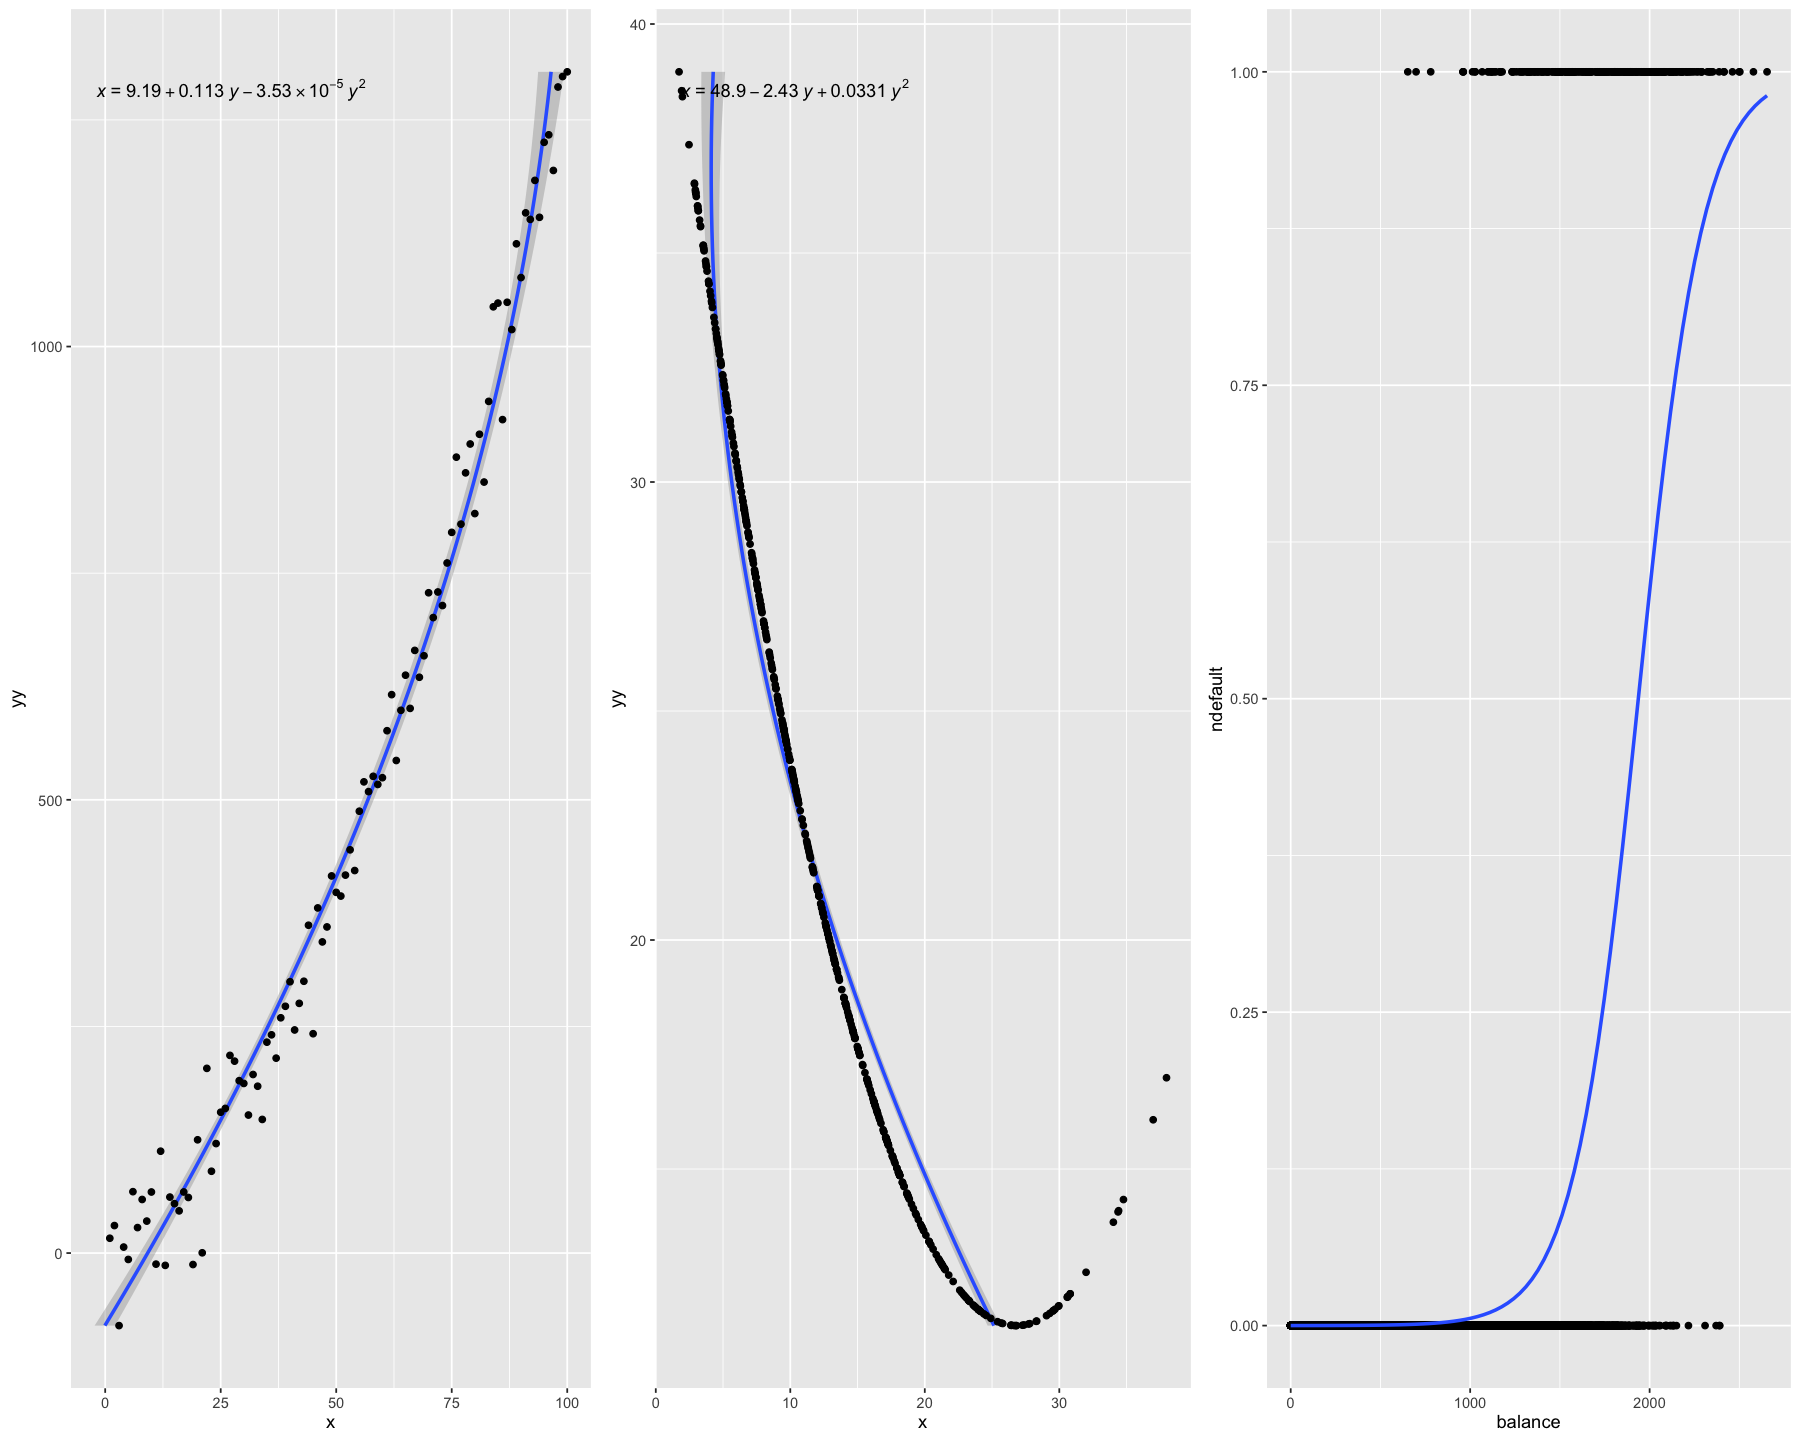

In [16]:
grid.arrange(f1, f2, f3, ncol = 3)

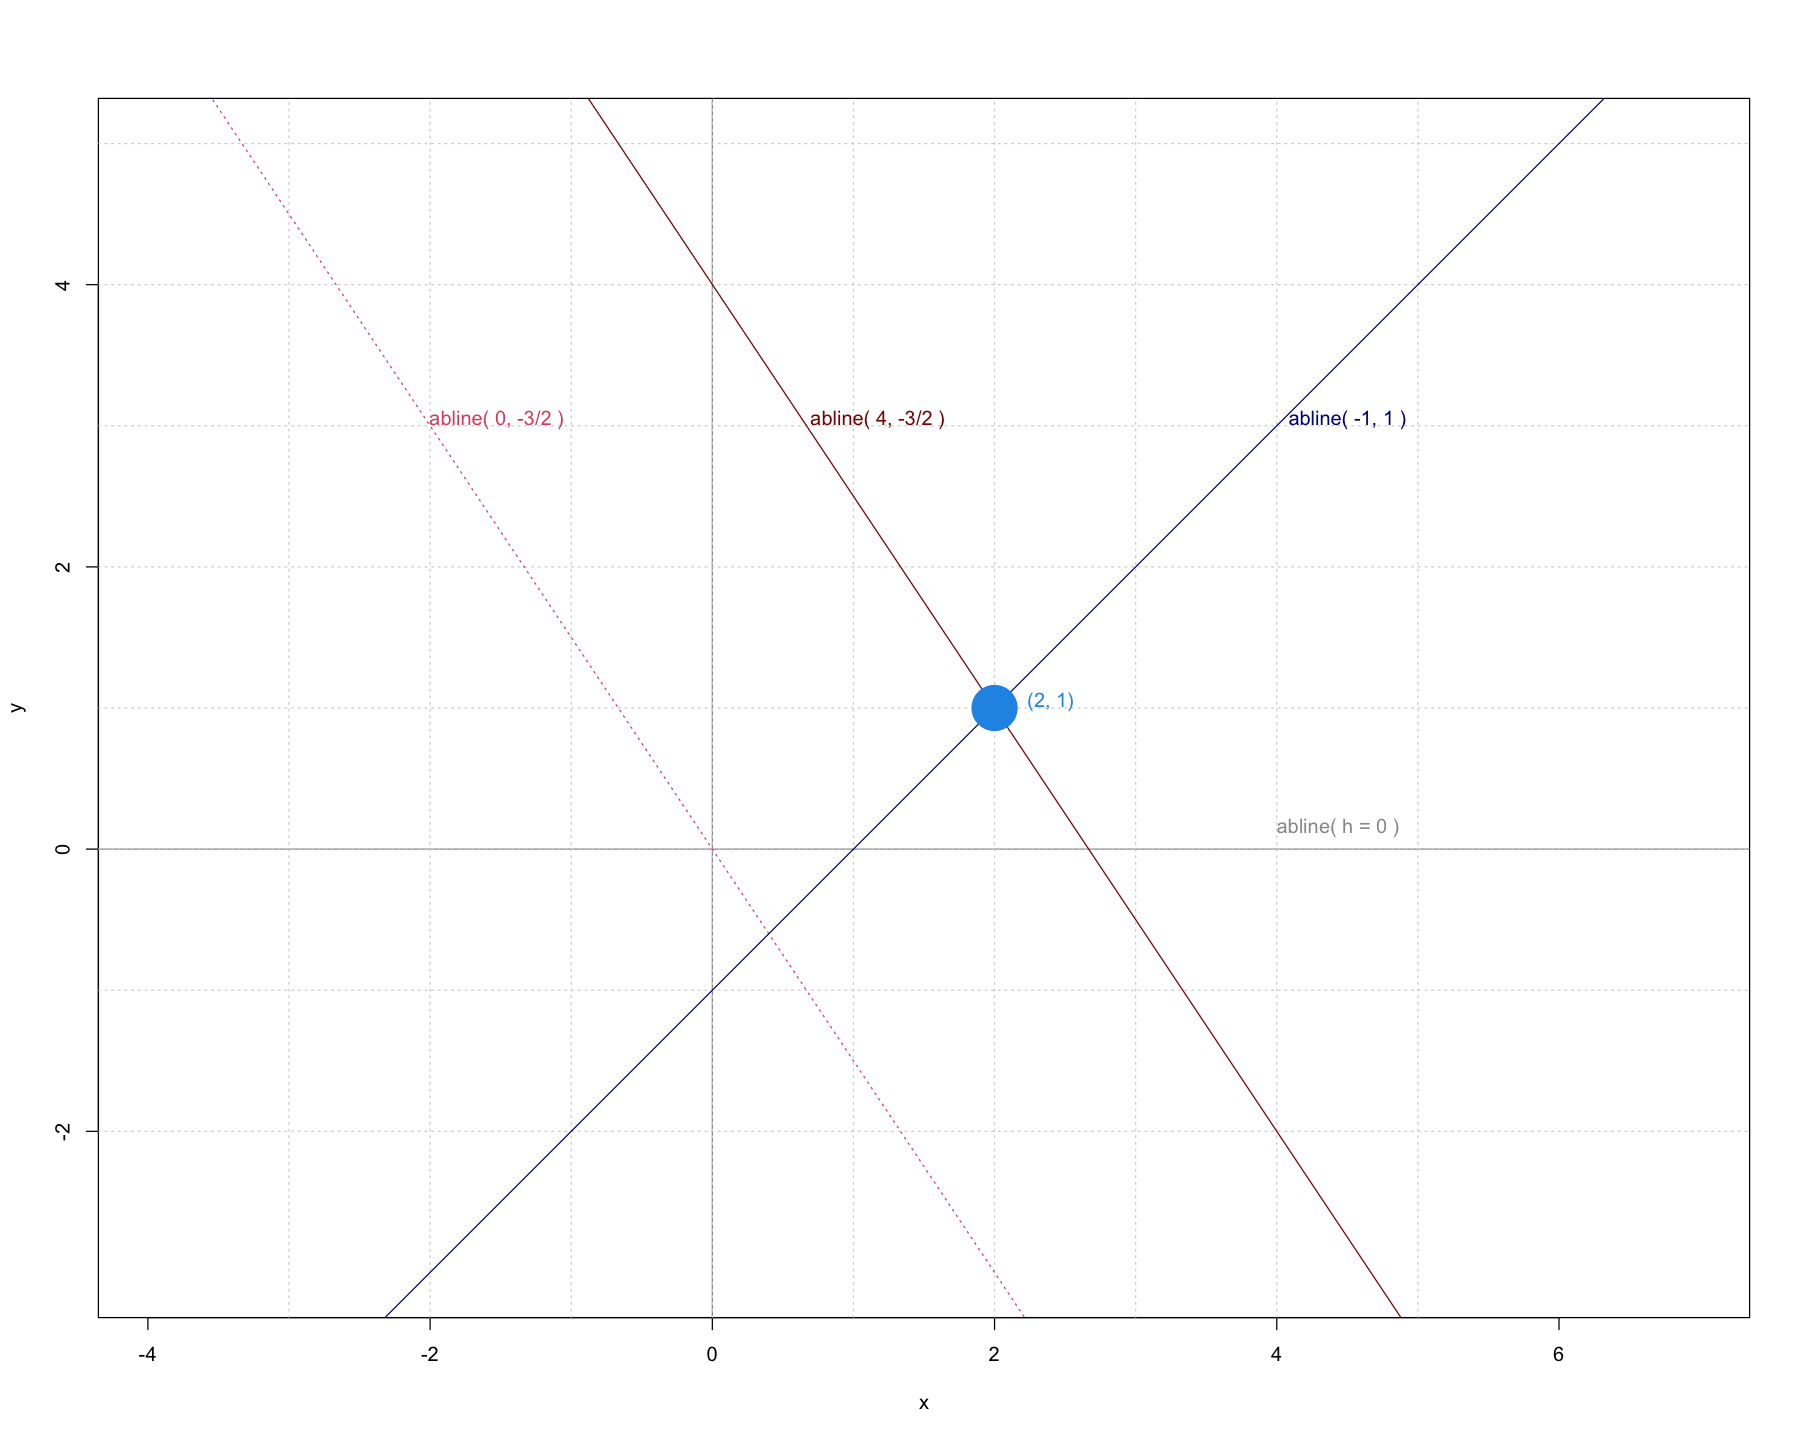

In [33]:
options(repr.plot.width = 15, repr.plot.height = 12)
plot(c(-2,5), c(-3,5), type = "n", xlab = "x", ylab = "y", asp = 1)
## the x- and y-axis, and an integer grid
abline(h = 0, v = 0, col = "gray60")
text(4, 0.1, "abline( h = 0 )", col = "gray60", adj = c(0, -.2))
abline(h = -2:5, v = -3:5, col = "lightgray", lty = 3)
abline(a = 4, b = -3/2, col = "darkred")
text(0.6, 3, "abline( 4, -3/2 )", col = "darkred", adj = c(-.1, -.1))
abline(a = 0, b = -3/2, col = 2, lty = 3)
text(-2.1, 3, "abline( 0, -3/2 )", col = 2, adj = c(-.1, -.1))
abline(a = -1, b = 1, col= "darkblue")
text(4, 3, "abline( -1, 1 )", col = "darkblue", adj = c(-.1, -.1))
points(c(2), c(1), pch = 19, col=4, cex=5)
text(2.2, 1, "(2, 1)", col=4, adj=c(-.1, -.1))